In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Part 2.2 Euler Forward Test:

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Problem parameters
lam = 5000.0  # Stiffness parameter (large = stiff!)

# Define the ODE: dy/dt = f(t, y), mechanical system with high damping
def f(t, x):    
    return -lam * x + 0.002 * np.sin(t)
                             
def x_exact(t):
    return 500*np.exp(-5000*t) + 4e-7 * np.sin(t)

Attempting Euler's Forward with h = 0.01...


<ipython-input-2-97ce28ce164b>:9: RuntimeWarning: overflow encountered in double_scalars
  return -lam * x + 0.002 * np.sin(t)
<ipython-input-3-7abd5f0f8160>:19: RuntimeWarning: invalid value encountered in double_scalars
  x[n+1] = x[n] + h * f(t[n], x[n])


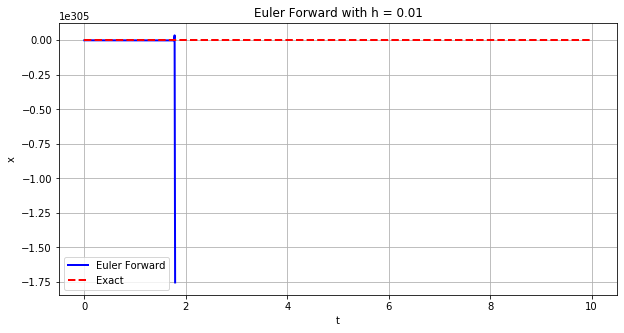

Maximum value reached: nan

Trying with h = 0.0001...


/opt/conda/lib/python3.8/site-packages/IPython/core/pylabtools.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


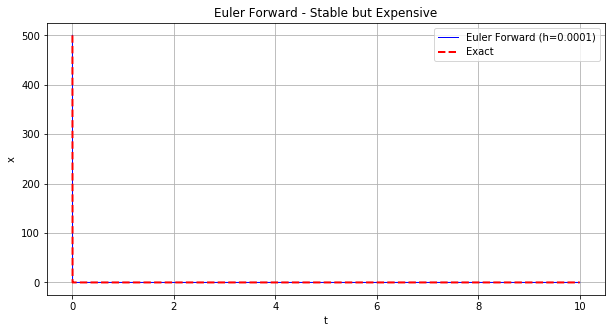

Number of steps needed: 100001
Maximum error: 5.89e+01


In [3]:
def euler_forward(f, x0, t0, t_final, h):
    """
    Euler's Forward method (explicit)

    y_{n+1} = y_n + h * f(t_n, y_n)

    Returns: arrays of time and solution
    """
    # Setup
    num_steps = int((t_final - t0) / h)
    t = np.zeros(num_steps + 1)
    x = np.zeros(num_steps + 1)

    t[0] = t0
    x[0] = x0

    # Time stepping
    for n in range(num_steps):
        x[n+1] = x[n] + h * f(t[n], x[n])
        t[n+1] = t[n] + h

    return t, x
# Initial condition
x0 = 500.0
t0 = 0.0
t_final = 10.0

# Try Euler's Forward with h = 0.01
h_forward = 0.01
print(f"Attempting Euler's Forward with h = {h_forward}...")

try:
    t_forward, x_forward = euler_forward(f, x0, t0, t_final, h_forward)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(t_forward, x_forward, 'b-', label='Euler Forward', linewidth=2)
    plt.plot(t_forward, x_exact(t_forward), 'r--', label='Exact', linewidth=2)
    plt.xlabel('t')
    plt.ylabel('x')
    plt.title(f'Euler Forward with h = {h_forward}')
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Maximum value reached: {np.max(np.abs(x_forward)):.2e}")
except:
    print("Solution blew up!")
# Try with MUCH smaller step size
h_forward_stable = 0.0001

print(f"\nTrying with h = {h_forward_stable}...")
t_forward, x_forward = euler_forward(f, x0, t0, t_final, h_forward_stable)

plt.figure(figsize=(10, 5))
plt.plot(t_forward, x_forward, 'b-', label=f'Euler Forward (h={h_forward_stable})', linewidth=1)
plt.plot(t_forward, x_exact(t_forward), 'r--', label='Exact', linewidth=2)
plt.xlabel('t')
plt.ylabel('x')
plt.title('Euler Forward - Stable but Expensive')
plt.legend()
plt.grid(True)
plt.show()

print(f"Number of steps needed: {len(t_forward)}")
print(f"Maximum error: {np.max(np.abs(x_forward - x_exact(t_forward))):.2e}")

## Part 2.3 Backward Euler with Newton-Raphson Implementation:

### Defining the Residual Function:

In [4]:
def residual(x_next, x_n, t_next, h):
    """
    Residual function for implicit Euler.

    We want to solve: x_{n+1} = x_n + h * f(t_{n+1}, x_{n+1})

    Rearrange: g(x_{n+1}) = x_{n+1} - x_n - h*f(t_{n+1}, x_{n+1}) = 0

    Parameters:
    - x_next: the unknown x_{n+1} we're solving for
    - x_n: the known value at previous time step
    - t_next: time t_{n+1}
    - h: step size

    Returns: residual g(x_{n+1})
    """
    return x_next - x_n - h * f(t_next, x_next)
# Test the residual
t_test = 1.0
h_test = 0.1
x_n_test = x_exact(t_test)
x_next_test = x_exact(t_test + h_test)

g_test = residual(x_next_test, x_n_test, t_test + h_test, h_test)
print(f"Residual when using exact solution: {g_test:.2e}")
print("(Should be very close to zero)")

Residual when using exact solution: 1.99e-08
(Should be very close to zero)


In [5]:
def residual_derivative(h):
    """
    Derivative of residual with respect to x_{n+1}.

    For our problem: f(t,x) = -lambda*y + g(t)
    So: df/dy = -lambda

    Therefore: g'(x_{n+1}) = 1 - h*(df/dy) = 1 - h*(-lambda) = 1 + lambda*h

    This is CONSTANT for our problem!

    Parameters:
    - h: step size

    Returns: g'(x_{n+1})
    """
    df_dy = -lam  # For our specific problem
    return 1 - h * df_dy
# Verify with finite differences
def residual_derivative_numerical(x_next, x_n, t_next, h, eps=1e-8):
    """Numerical approximation of g' using finite differences"""
    return (residual(x_next + eps, x_n, t_next, h) - 
            residual(x_next - eps, x_n, t_next, h)) / (2 * eps)

# Test at a random point
x_test = 0.5
g_prime_analytical = residual_derivative(h_test)
g_prime_numerical = residual_derivative_numerical(x_test, x_n_test, t_test, h_test)

print(f"Analytical g': {g_prime_analytical:.6f}")
print(f"Numerical g':  {g_prime_numerical:.6f}")
print(f"Difference:    {abs(g_prime_analytical - g_prime_numerical):.2e}")

Analytical g': 501.000000
Numerical g':  501.000001
Difference:    9.52e-07


In [6]:
def newton_raphson_step(x_n, t_next, h, tol=1e-8, max_iter=20, verbose=False):
    """
    Solve for x_{n+1} using Newton-Raphson iteration.

    We want to find x_{n+1} such that g(x_{n+1}) = 0

    Newton-Raphson: x^(k+1) = x^(k) - g(x^(k)) / g'(x^(k))

    Parameters:
    - x_n: solution at previous time step
    - t_next: time t_{n+1}
    - h: step size
    - tol: convergence tolerance
    - max_iter: maximum iterations
    - verbose: print iteration details

    Returns: (x_{n+1}, number of iterations)
    """
    # Initial guess: use explicit Euler as predictor
    x_guess = x_n + h * f(t_next - h, x_n)  

    # Compute g' once (constant for our linear problem)
    g_prime = residual_derivative(h)

    if verbose:
        print(f"\n  Starting Newton-Raphson at t = {t_next:.4f}")
        print(f"  Initial guess: x = {x_guess:.6f}")
        print(f"  g'(constant) = {g_prime:.6f}\n")

    # Newton-Raphson iteration
    for k in range(max_iter):
        # Evaluate residual
        g = residual(x_guess, x_n, t_next, h)

        if verbose:
            print(f"  Iteration {k}: x = {x_guess:.6f}, g = {g:.2e}")

        # Check convergence
        if abs(g) < tol:
            if verbose:
                print(f"  ✓ Converged in {k} iterations!\n")
            return x_guess, k

        # Newton-Raphson update
        delta = -g / g_prime
        x_guess = x_guess + delta

    # Did not converge
    print(f"  ✗ Warning: Newton-Raphson did not converge after {max_iter} iterations")
    return y_guess, max_iter
# Test Newton-Raphson on one step
x_n = 1.0  # Initial condition
t_n = 0.0
h = 0.1

x_next, iters = newton_raphson_step(x_n, t_n + h, h, verbose=True)

print(f"Result: x({t_n + h}) = {x_next:.6f}")
print(f"Exact:  x({t_n + h}) = {x_exact(t_n + h):.6f}")
print(f"Error:  {abs(x_next - x_exact(t_n + h)):.2e}")


  Starting Newton-Raphson at t = 0.1000
  Initial guess: x = -499.000000
  g'(constant) = 501.000000

  Iteration 0: x = -499.000000, g = -2.50e+05
  Iteration 1: x = 0.001996, g = -6.24e-12
  ✓ Converged in 1 iterations!

Result: x(0.1) = 0.001996
Exact:  x(0.1) = 0.000000
Error:  2.00e-03


In [7]:
def euler_backward(f, x0, t0, t_final, h, tol=1e-8, verbose_freq=0):
    """
    Euler's Backward (Implicit Euler) method with Newton-Raphson.

    For each time step:
    1. Solve x_{n+1} = x_n + h*f(t_{n+1}, x_{n+1}) using Newton-Raphson
    2. Move to next time step

    Parameters:
    - f: ODE function dy/dt = f(t, x)
    - x0: initial condition
    - t0, t_final: time span
    - h: step size
    - tol: Newton-Raphson tolerance
    - verbose_freq: print details every N steps (0 = no printing)

    Returns:
    - t: array of time points
    - x: array of solution values
    - iterations: array of NR iterations per step
    """
    # Setup
    num_steps = int((t_final - t0) / h)
    t = np.zeros(num_steps + 1)
    x = np.zeros(num_steps + 1)
    iterations = np.zeros(num_steps, dtype=int)

    # Initial condition
    t[0] = t0
    x[0] = x0

    print(f"Starting Euler's Backward method:")
    print(f"  Time span: [{t0}, {t_final}]")
    print(f"  Step size: h = {h}")
    print(f"  Number of steps: {num_steps}")
    print(f"  NR tolerance: {tol}\n")

    # Time stepping loop
    for n in range(num_steps):
        # Solve for x_{n+1} using Newton-Raphson
        verbose = (verbose_freq > 0 and (n % verbose_freq == 0))

        x[n+1], iterations[n] = newton_raphson_step(
            x[n], t[n] + h, h, tol=tol, verbose=verbose
        )

        t[n+1] = t[n] + h

    print(f"✓ Completed!")
    print(f"  Average NR iterations per step: {np.mean(iterations):.2f}")
    print(f"  Max NR iterations: {np.max(iterations)}")
    print(f"  Min NR iterations: {np.min(iterations)}\n")

    return t, x, iterations

TEST 1: h = 0.1 (very large for a stiff problem)
Starting Euler's Backward method:
  Time span: [0.0, 10.0]
  Step size: h = 0.1
  Number of steps: 100
  NR tolerance: 1e-08


  Starting Newton-Raphson at t = 0.1000
  Initial guess: x = -249500.000000
  g'(constant) = 501.000000

  Iteration 0: x = -249500.000000, g = -1.25e+08
  Iteration 1: x = 0.998004, g = -3.64e-09
  ✓ Converged in 1 iterations!


  Starting Newton-Raphson at t = 2.1000
  Initial guess: x = 0.000000
  g'(constant) = 501.000000

  Iteration 0: x = 0.000000, g = 1.82e-06
  Iteration 1: x = 0.000000, g = -1.96e-20
  ✓ Converged in 1 iterations!


  Starting Newton-Raphson at t = 4.1000
  Initial guess: x = -0.000000
  g'(constant) = 501.000000

  Iteration 0: x = -0.000000, g = -1.52e-06
  Iteration 1: x = -0.000000, g = 6.82e-21
  ✓ Converged in 1 iterations!


  Starting Newton-Raphson at t = 6.1000
  Initial guess: x = -0.000000
  g'(constant) = 501.000000

  Iteration 0: x = -0.000000, g = -5.60e-07
  Iteration 1

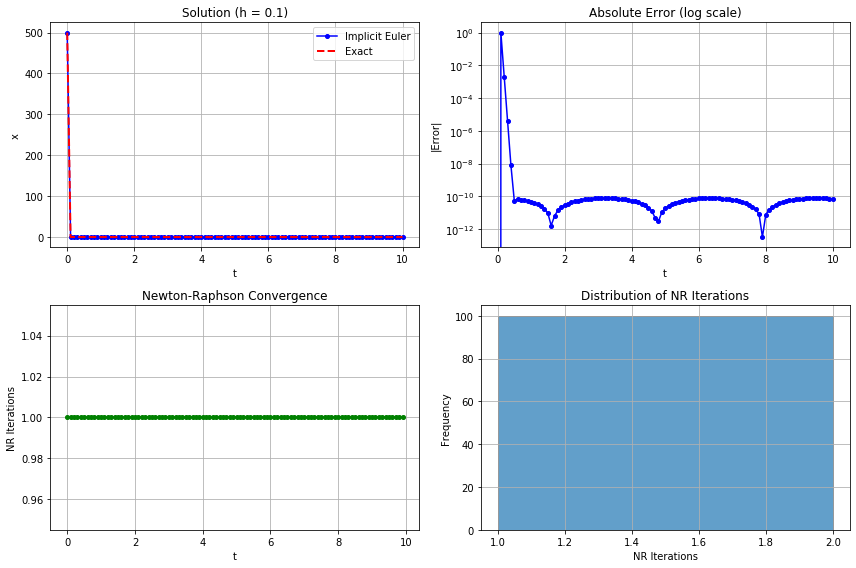

Maximum error: 9.98e-01
Number of steps: 101

TEST 2: h = 0.5 (extremely large)
Starting Euler's Backward method:
  Time span: [0.0, 10.0]
  Step size: h = 0.5
  Number of steps: 20
  NR tolerance: 1e-08

✓ Completed!
  Average NR iterations per step: 1.05
  Max NR iterations: 2
  Min NR iterations: 1



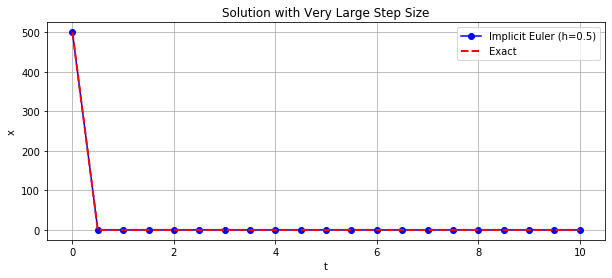

Maximum error: 2.00e-01
Number of steps: 21


In [8]:
# Test with h = 0.1 (100x larger than stable Euler Forward!)
print("=" * 60)
print("TEST 1: h = 0.1 (very large for a stiff problem)")
print("=" * 60)

h_backward = 0.1
t_backward, x_backward, iters = euler_backward(f, x0, t0, t_final, h_backward, verbose_freq=20)

# Plot results
plt.figure(figsize=(12, 8))

# Solution comparison
plt.subplot(2, 2, 1)
plt.plot(t_backward, x_backward, 'b-o', markersize=4, label='Implicit Euler')
plt.plot(t_backward, x_exact(t_backward), 'r--', linewidth=2, label='Exact')
plt.xlabel('t')
plt.ylabel('x')
plt.title(f'Solution (h = {h_backward})')
plt.legend()
plt.grid(True)

# Error
plt.subplot(2, 2, 2)
error = np.abs(x_backward - x_exact(t_backward))
plt.semilogy(t_backward, error, 'b-o', markersize=4)
plt.xlabel('t')
plt.ylabel('|Error|')
plt.title('Absolute Error (log scale)')
plt.grid(True)

# Newton-Raphson iterations
plt.subplot(2, 2, 3)
plt.plot(t_backward[:-1], iters, 'go-', markersize=4)
plt.xlabel('t')
plt.ylabel('NR Iterations')
plt.title('Newton-Raphson Convergence')
plt.grid(True)

# Histogram of iterations
plt.subplot(2, 2, 4)
plt.hist(iters, bins=range(int(np.min(iters)), int(np.max(iters))+2), edgecolor='black', alpha=0.7)
plt.xlabel('NR Iterations')
plt.ylabel('Frequency')
plt.title('Distribution of NR Iterations')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Maximum error: {np.max(error):.2e}")
print(f"Number of steps: {len(t_backward)}")
# Test with h = 0.5 (even bigger!)
print("\n" + "=" * 60)
print("TEST 2: h = 0.5 (extremely large)")
print("=" * 60)

h_large = 0.5
t_large, x_large, iters_large = euler_backward(f, x0, t0, t_final, h_large)

plt.figure(figsize=(10, 4))
plt.plot(t_large, x_large, 'b-o', markersize=6, label='Implicit Euler (h=0.5)')
plt.plot(t_large, x_exact(t_large), 'r--', linewidth=2, label='Exact')
plt.xlabel('t')
plt.ylabel('x')
plt.title('Solution with Very Large Step Size')
plt.legend()
plt.grid(True)
plt.show()

error_large = np.abs(x_large - x_exact(t_large))
print(f"Maximum error: {np.max(error_large):.2e}")
print(f"Number of steps: {len(t_large)}")